# Experiment 1: Entanglement and Bell's inequality
## Experimentalpraktikum A, Universität Innsbruck, WS 2025/26
### Zarah Aigner 

In [2]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import configparser
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import pandas as pd
from scipy.constants import e, c, h, nano
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.special import wofz
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, t as tdist

font1 = {'family':'sans-serif','color':'black','size':12}
font2 = {'family':'sans-serif','color':'black','size':20}

plt.rcParams['text.usetex'] = True #LaTeX

## Aufgabe 1: Measuring of the Visibility

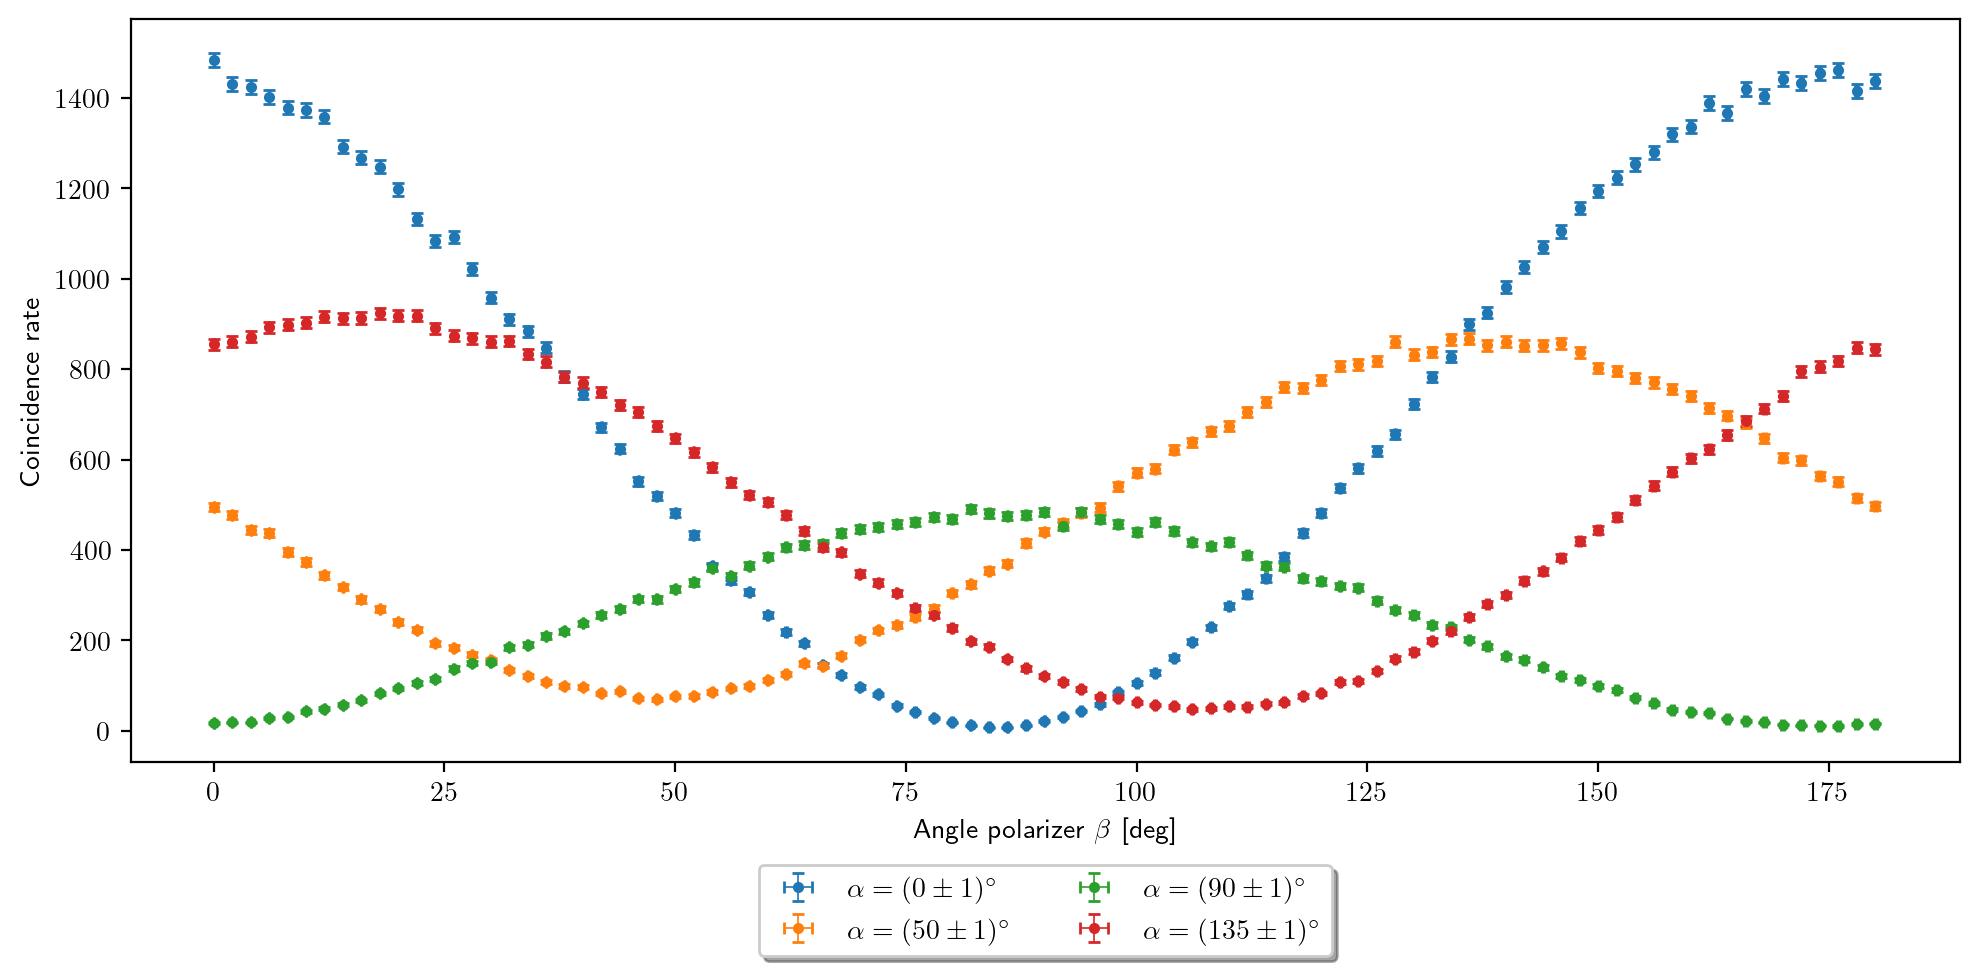

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A1_Co1 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/Entanglement_Bells_inequality/Data_Entanglement/group1visibility.txt"
data = pd.read_csv(A1_Co1, sep="\t")

angle = data["YAngle"].to_numpy(dtype=float)
angle_err = 0.001 * angle

t_exp = 6.0

plt.figure(figsize=(10, 5), dpi=200)

# Mapping: (DataFrame-Spalte, Legendenlabel)
series = [
    ("Co_1", r"$\alpha = (0\pm1)^{\circ}$"),
    ("Co_2", r"$\alpha = (50\pm1)^{\circ}$"),
    ("Co_3", r"$\alpha = (90\pm1)^{\circ}$"),
    ("Co_4", r"$\alpha = (135\pm1)^{\circ}$"),
]

for colname, label in series:
    N = data[colname].to_numpy(dtype=float)

    rate = N / t_exp
    rate_err = np.sqrt(N) / t_exp

    plt.errorbar(
        angle, rate,
        xerr=angle_err,
        yerr=rate_err,
        fmt='o',
        linestyle='none',
        markersize=3,
        elinewidth=0.6,
        capsize=2,
        label=label
    )

plt.xlabel(r"Angle polarizer $\beta$ [deg]")
plt.ylabel(r"Coincidence rate")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig("A1_Co_rates.pdf")
plt.show()


### Computing the Visibility in the HV Base

#### V_HV = (N_HV + N_VH - N_HH - N_VV) / (N_HV + N_VH + N_HH + N_VV)

In [15]:
import numpy as np
import pandas as pd

data = pd.read_csv(A1_Co1, sep="\t")

beta = data["YAngle"].to_numpy(dtype=float)

# Indizes für beta = 0° und 90°
i0  = np.where(np.isclose(beta, 0, atol=0.5))[0]
i90 = np.where(np.isclose(beta, 90, atol=0.5))[0]


if len(i0) != 1 or len(i90) != 1:
    raise ValueError(f"Erwarte genau je einen Eintrag für beta=0 und 90. "
                     f"Gefunden: beta=0 -> {len(i0)}, beta=90 -> {len(i90)}")

i0, i90 = int(i0[0]), int(i90[0])

# Mapping: welche Co-Spalte entspricht welchem alpha?
col_alpha0  = "Co_1"  # alpha = 0°
col_alpha90 = "Co_3"  # alpha = 90°

N_HH = float(data.loc[i0,  col_alpha0])   # alpha=0,  beta=0
N_HV = float(data.loc[i90, col_alpha0])   # alpha=0,  beta=90
N_VH = float(data.loc[i0,  col_alpha90])  # alpha=90, beta=0
N_VV = float(data.loc[i90, col_alpha90])  # alpha=90, beta=90

N_par  = N_HH + N_VV
N_perp = N_HV + N_VH

V = (N_par - N_perp) / (N_par + N_perp)

A, B = N_par, N_perp
dVdA = 2*B / (A+B)**2
dVdB = -2*A / (A+B)**2

sigma_A = np.sqrt(A)
sigma_B = np.sqrt(B)

sigma_V = np.sqrt((dVdA*sigma_A)**2 + (dVdB*sigma_B)**2)

print(f"V_HV = {V:.3f} ± {sigma_V:.3f}")


V_HV = 0.963 ± 0.002


#### 2 Methode anwenden -> fitting method

In [19]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

data = pd.read_csv(A1_Co1, sep="\t")

beta_deg = data["YAngle"].to_numpy(dtype=float)
beta = np.deg2rad(beta_deg)
t_exp = 6.0

def model(beta, A, B, beta0, alpha_rad):
    return A + B*np.cos(2*(alpha_rad - beta - beta0))

def fit_visibility(colname, alpha_deg):
    N = data[colname].to_numpy(dtype=float)
    y = N / t_exp
    sigma = np.sqrt(np.maximum(N, 1.0)) / t_exp

    alpha_rad = np.deg2rad(alpha_deg)
    f = lambda b, A, B, beta0: model(b, A, B, beta0, alpha_rad)

    A0 = np.mean(y)
    B0 = (np.max(y) - np.min(y)) / 2
    beta00 = 0.0

    popt, pcov = curve_fit(f, beta, y, p0=[A0, B0, beta00], sigma=sigma, absolute_sigma=True)
    A, B, beta0 = popt

    V = abs(B)/abs(A)

    # Fehler mit Kovarianz (Korrelation A,B berücksichtigt)
    sA = np.sign(A) if A != 0 else 1.0
    sB = np.sign(B) if B != 0 else 1.0
    dVdA = -abs(B)/(abs(A)**2) * sA
    dVdB = (1/abs(A)) * sB

    varV = dVdA**2*pcov[0,0] + dVdB**2*pcov[1,1] + 2*dVdA*dVdB*pcov[0,1]
    sV = np.sqrt(max(varV, 0.0))

    return V, sV, (A, B, beta0)

V_H, sV_H, pars_H = fit_visibility("Co_1", 0)    # H
V_V, sV_V, pars_V = fit_visibility("Co_3", 90)   # V

print(f"V_H (α=0°)  = {V_H:.4f} ± {sV_H:.4f}")
print(f"V_V (α=90°) = {V_V:.4f} ± {sV_V:.4f}")

V_HV_2 = 0.5*(V_H + V_V)
sV_HV_2 = 0.5*np.sqrt(sV_H**2 + sV_V**2)  # nur Statistik
print(f"V_HV,2 (mean) = {V_HV_2:.4f} ± {sV_HV_2:.4f}")


V_H (α=0°)  = 0.9905 ± 0.0006
V_V (α=90°) = 0.9564 ± 0.0016
V_HV,2 (mean) = 0.9735 ± 0.0009


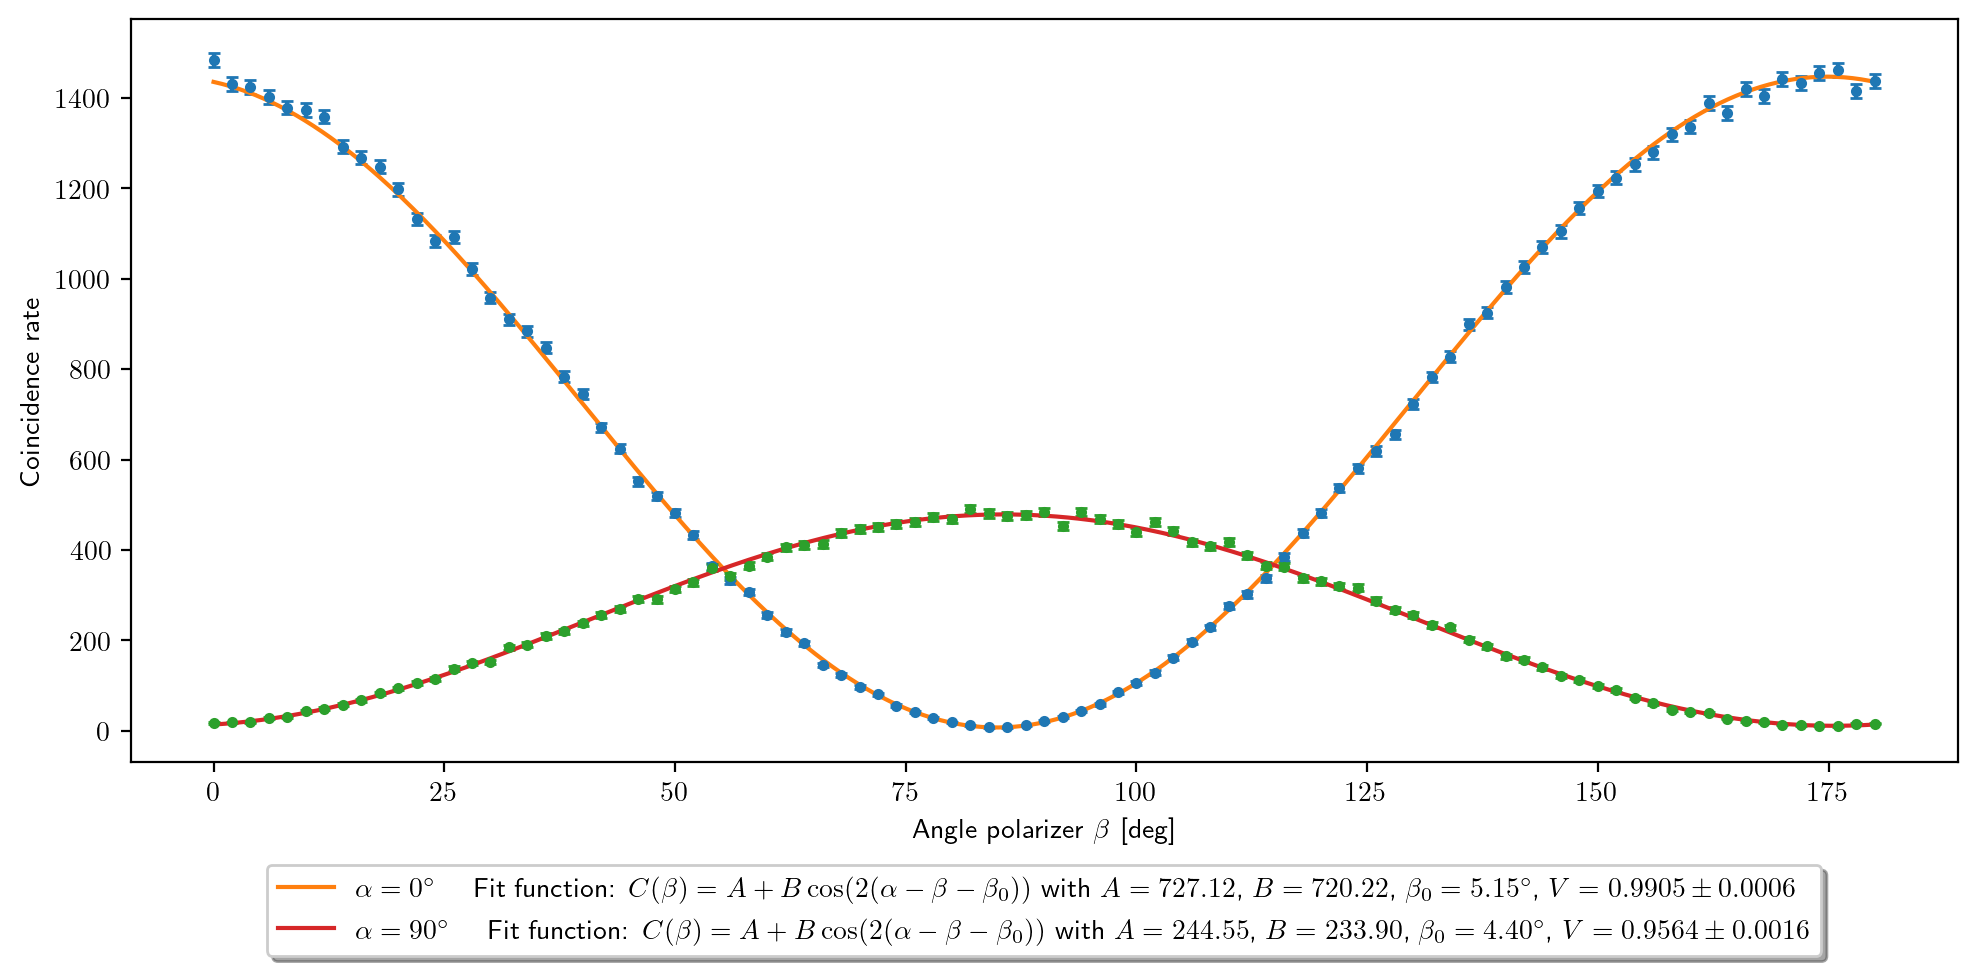

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = pd.read_csv(A1_Co1, sep="\t")

beta_deg = data["YAngle"].to_numpy(dtype=float)
beta = np.deg2rad(beta_deg)

t_exp = 6.0

def model(beta, A, B, beta0, alpha_rad):
    return A + B*np.cos(2*(alpha_rad - beta - beta0))

def fit_visibility(colname, alpha_deg):
    N = data[colname].to_numpy(dtype=float)
    y = N / t_exp
    sigma = np.sqrt(np.maximum(N, 1.0)) / t_exp

    alpha_rad = np.deg2rad(alpha_deg)
    f = lambda b, A, B, beta0: model(b, A, B, beta0, alpha_rad)

    A0 = np.mean(y)
    B0 = (np.max(y) - np.min(y)) / 2
    beta00 = 0.0

    popt, pcov = curve_fit(
        f, beta, y,
        p0=[A0, B0, beta00],
        sigma=sigma,
        absolute_sigma=True
    )

    A, B, beta0 = popt
    V = abs(B) / abs(A)

    # Fehler mit Korrelation
    sA = np.sign(A) if A != 0 else 1.0
    sB = np.sign(B) if B != 0 else 1.0
    dVdA = -abs(B)/(abs(A)**2) * sA
    dVdB = (1/abs(A)) * sB

    varV = (
        dVdA**2 * pcov[0,0]
        + dVdB**2 * pcov[1,1]
        + 2*dVdA*dVdB*pcov[0,1]
    )

    sV = np.sqrt(max(varV, 0.0))
    return y, sigma, popt, sV, V

def fit_label(alpha_deg, A, B, beta0, V, sV):
    return (
        rf"$\alpha={alpha_deg}^\circ$"
        rf"$\quad$ Fit function: $C(\beta)=A+B\cos(2(\alpha-\beta-\beta_0))$ with "
        rf"$A={A:.2f}$, $B={B:.2f}$, "
        rf"$\beta_0={np.rad2deg(beta0):.2f}^\circ$, "
        rf"$V={V:.4f}\pm{sV:.4f}$"
    )

plt.figure(figsize=(10,5), dpi=200)

for col, alpha_deg in [("Co_1", 0), ("Co_3", 90)]:
    y, sigma, popt, sV, V = fit_visibility(col, alpha_deg)
    A, B, beta0 = popt

    beta_fine = np.linspace(beta.min(), beta.max(), 600)
    alpha_rad = np.deg2rad(alpha_deg)
    yfit = model(beta_fine, A, B, beta0, alpha_rad)

    label = fit_label(alpha_deg, A, B, beta0, V, sV)

    plt.errorbar(
        beta_deg, y,
        yerr=sigma,
        fmt='o',
        markersize=3,
        capsize=2,
        linestyle='none'
    )

    plt.plot(
        np.rad2deg(beta_fine),
        yfit,
        linewidth=1.5,
        label=label
    )

plt.xlabel(r"Angle polarizer $\beta$ [deg]")
plt.ylabel(r"Coincidence rate")
#plt.legend(fontsize=9)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig("HV_visibility_fitted.pdf")
plt.show()



### Computing the visibility in the AB base

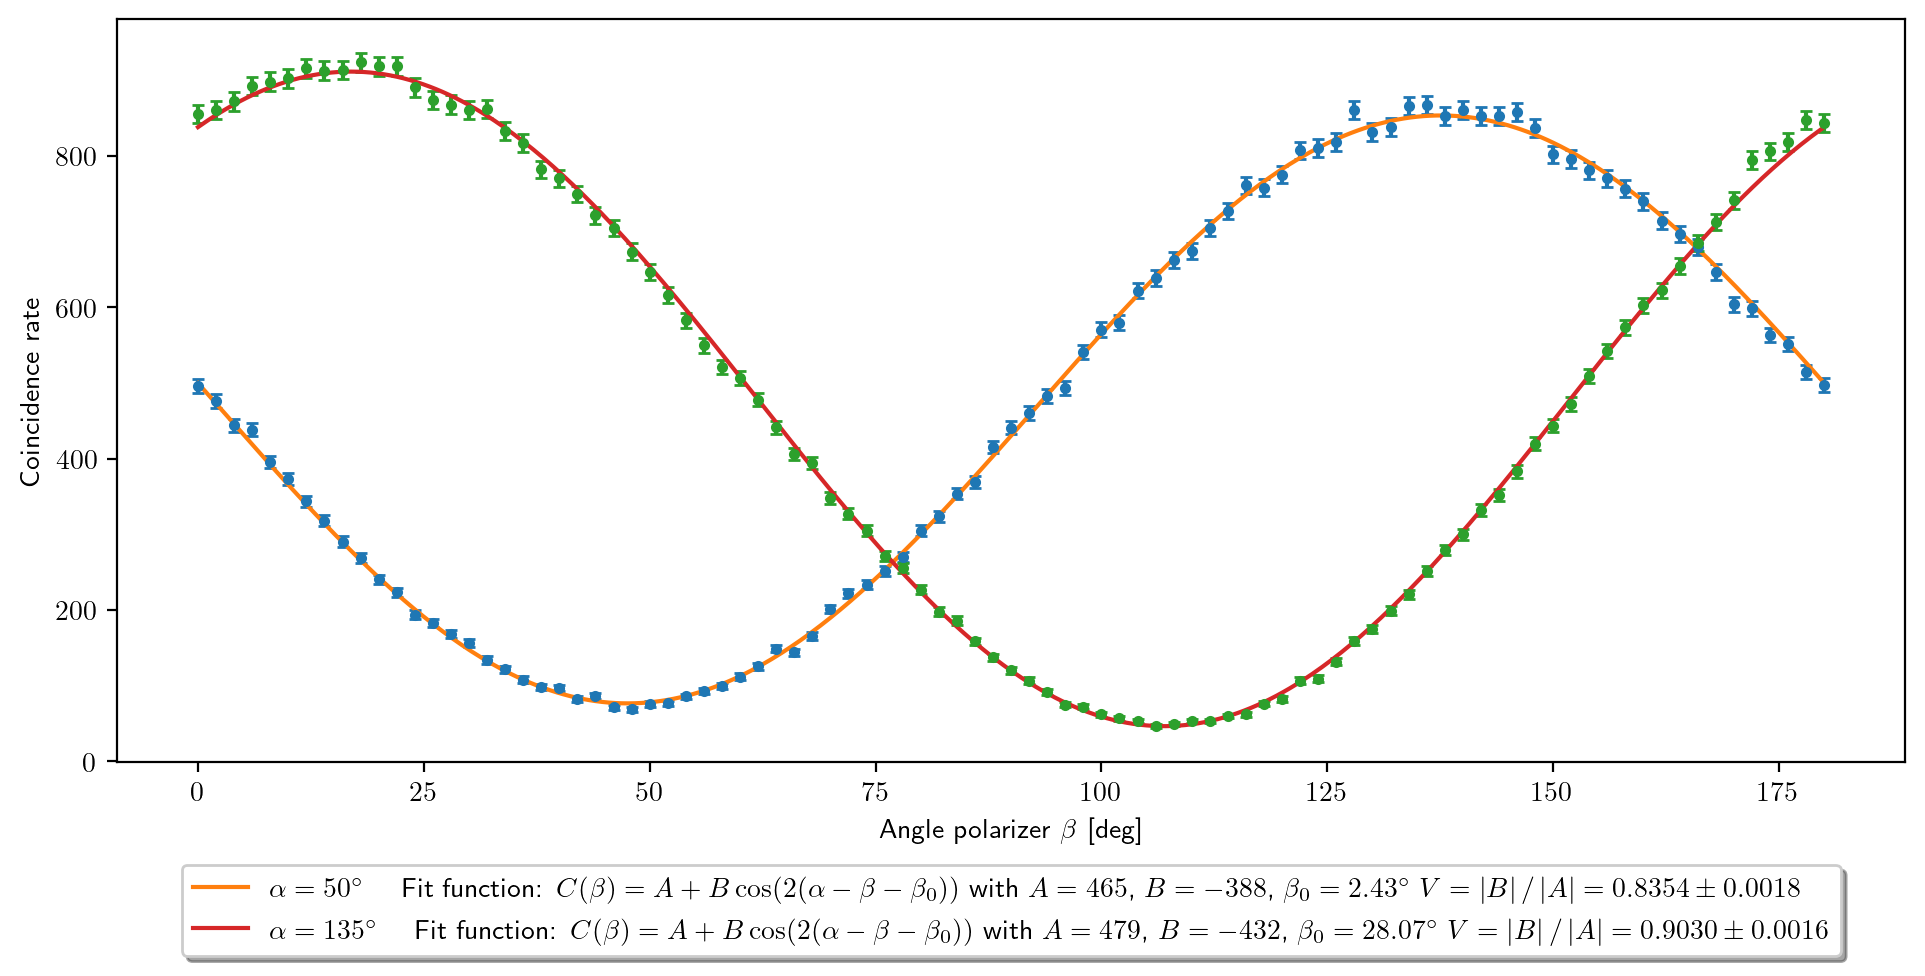

Co_2 (α=50°): A=465.001, B=-388.454, beta0=2.430°, V = 0.8354 ± 0.0018
Co_4 (α=135°): A=478.92, B=-432.487, beta0=28.067°, V = 0.9030 ± 0.0016


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = pd.read_csv(A1_Co1, sep="\t")

beta_deg = data["YAngle"].to_numpy(dtype=float)
beta = np.deg2rad(beta_deg)

t_exp = 6.0  # s

def model(beta, A, B, beta0, alpha_rad):
    return A + B * np.cos(2*(alpha_rad - beta - beta0))

def fit_one_series(beta, N, alpha_deg):
    # Raten + Poissonfehler für Raten
    y = N / t_exp
    sigma = np.sqrt(np.maximum(N, 1.0)) / t_exp  # avoid zero sigma

    alpha_rad = np.deg2rad(alpha_deg)

    # Startwerte
    A0 = np.mean(y)
    B0 = (np.max(y) - np.min(y)) / 2
    beta00 = 0.0

    # curve_fit braucht Funktion ohne alpha_rad als Fitparameter
    f = lambda b, A, B, beta0: model(b, A, B, beta0, alpha_rad)

    popt, pcov = curve_fit(
        f, beta, y,
        p0=[A0, B0, beta00],
        sigma=sigma,
        absolute_sigma=True
    )
    A, B, beta0 = popt

    # Visibility
    V = abs(B) / abs(A)

    # Fehler mit Kovarianz (Korrelation A,B berücksichtigt)
    sA = np.sign(A) if A != 0 else 1.0
    sB = np.sign(B) if B != 0 else 1.0

    dVdA = -abs(B) / (abs(A)**2) * sA
    dVdB = (1.0/abs(A)) * sB

    varV = dVdA**2 * pcov[0,0] + dVdB**2 * pcov[1,1] + 2*dVdA*dVdB*pcov[0,1]
    sigmaV = np.sqrt(max(varV, 0.0))

    return (A, B, beta0, V, sigmaV, popt, pcov, y, sigma)

def legend_label(alpha_deg, A, B, beta0, V, sV):
    # Mehrzeilig, Formel + Parameter in Legende
    return (
        rf"$\alpha={alpha_deg}^\circ$"
        rf"$\quad$ Fit function: $C(\beta)=A+B\cos(2(\alpha-\beta-\beta_0))$ with "
        rf"$A={A:.3g}$, $B={B:.3g}$, $\beta_0={np.rad2deg(beta0):.2f}^\circ$ " 
        rf"$V=\left|B\right|/\left|A\right|={V:.4f}\pm{sV:.4f}$"
    )

# Mapping: welche Co-Spalte entspricht welchem alpha?
# Nur D/A-Basis
series = [
    ("Co_2", 50),    # D (eigentlich 45°, gemessen 50°)
    ("Co_4", 135),   # A
]


results = {}

plt.figure(figsize=(10,5), dpi=200)

for col, alpha_deg in series:
    N = data[col].to_numpy(dtype=float)
    A, B, beta0, V, sV, popt, pcov, y, sigma = fit_one_series(beta, N, alpha_deg)
    results[col] = (alpha_deg, V, sV, A, B, beta0)

    # Fitkurve zum Plotten
    beta_fine = np.linspace(beta.min(), beta.max(), 500)
    alpha_rad = np.deg2rad(alpha_deg)
    yfit = model(beta_fine, A, B, beta0, alpha_rad)

    # Datenpunkte OHNE label (sonst doppelte Legende)
    plt.errorbar(
        beta_deg, y,
        yerr=sigma,
        fmt='o',
        linestyle='none',
        markersize=3,
        capsize=2
    )

    # Fitlinie MIT ausführlichem label
    plt.plot(
        np.rad2deg(beta_fine),
        yfit,
        linewidth=1.5,
        label=legend_label(alpha_deg, A, B, beta0, V, sV)
    )

plt.xlabel(r"Angle polarizer $\beta$ [deg]")
plt.ylabel(r"Coincidence rate")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1, fancybox=True, shadow=True)
plt.tight_layout()
plt.savefig("DA_visibility_fitted.pdf")
plt.show()

for col, (alpha_deg, V, sV, A, B, beta0) in results.items():
    print(f"{col} (α={alpha_deg}°): A={A:.6g}, B={B:.6g}, beta0={np.rad2deg(beta0):.3f}°, V = {V:.4f} ± {sV:.4f}")


## Aufgabe 2: Determining of the Bell parameter

In [45]:
files = {
    (0, 22.5):   "3.txt",
    (0, 112.5):  "1.txt",
    (90, 22.5):  "12.txt",
    (90, 112.5): "10.txt",

    (0, 67.5):   "4.txt",
    (0, 157.5):  "2.txt",
    (90, 67.5):  "11.txt",
    (90, 157.5): "9.txt",

    (45, 22.5):   "6.txt",
    (45, 112.5):  "7.txt",
    (135, 22.5):  "13.txt",
    (135, 112.5): "15.txt",

    (45, 67.5):   "5.txt",
    (45, 157.5):  "8.txt",
    (135, 67.5):  "14.txt",
    (135, 157.5): "16.txt",
}

import numpy as np
import pandas as pd

Nrep = 60

def read_coincidences(filename):
    data = pd.read_csv(
        filename,
        sep="\t",
        comment="#",
        header=None,
        names=["time_ms", "ch1", "ch2", "coinc"]
    )
    return data["coinc"].to_numpy(dtype=float)

def mean_and_error_poisson(counts):
    Cbar = np.mean(counts)
    dCbar = np.sqrt(Cbar / Nrep)
    return Cbar, dCbar

def expectation_value(file_pp, file_pm, file_mp, file_mm):
    Cpp, dCpp = mean_and_error_poisson(read_coincidences(file_pp))
    Cpm, dCpm = mean_and_error_poisson(read_coincidences(file_pm))
    Cmp, dCmp = mean_and_error_poisson(read_coincidences(file_mp))
    Cmm, dCmm = mean_and_error_poisson(read_coincidences(file_mm))

    num = Cpp + Cmm - Cpm - Cmp
    den = Cpp + Cmm + Cpm + Cmp
    E = num / den

    # Fehlerfortpflanzung (unabhängig, Poisson)
    dE = np.sqrt(
        (2*(Cpm+Cmp)/den**2 * dCpp)**2 +
        (2*(Cpm+Cmp)/den**2 * dCmm)**2 +
        (2*(Cpp+Cmm)/den**2 * dCpm)**2 +
        (2*(Cpp+Cmm)/den**2 * dCmp)**2
    )
    return E, dE

E_ab, dE_ab = expectation_value(
    files[(0,22.5)], files[(0,112.5)],
    files[(90,22.5)], files[(90,112.5)]
)

E_abp, dE_abp = expectation_value(
    files[(0,67.5)], files[(0,157.5)],
    files[(90,67.5)], files[(90,157.5)]
)

E_apb, dE_apb = expectation_value(
    files[(45,22.5)], files[(45,112.5)],
    files[(135,22.5)], files[(135,112.5)]
)

E_apbp, dE_apbp = expectation_value(
    files[(45,67.5)], files[(45,157.5)],
    files[(135,67.5)], files[(135,157.5)]
)

# --- Compute and print the four expectation values used for CHSH ---

# Dictionary to store results in a structured way
E_values = {}

# 1) E(alpha, beta)
E_values["E(alpha,beta)"] = expectation_value(
    files[(0, 22.5)],    # C++
    files[(0, 112.5)],   # C+-
    files[(90, 22.5)],   # C-+
    files[(90, 112.5)]   # C--
)

# 2) E(alpha, beta')
E_values["E(alpha,beta')"] = expectation_value(
    files[(0, 67.5)],
    files[(0, 157.5)],
    files[(90, 67.5)],
    files[(90, 157.5)]
)

# 3) E(alpha', beta)
E_values["E(alpha',beta)"] = expectation_value(
    files[(45, 22.5)],
    files[(45, 112.5)],
    files[(135, 22.5)],
    files[(135, 112.5)]
)

# 4) E(alpha', beta')
E_values["E(alpha',beta')"] = expectation_value(
    files[(45, 67.5)],
    files[(45, 157.5)],
    files[(135, 67.5)],
    files[(135, 157.5)]
)

# --- Print results in a report-ready format ---
print("\nExpectation values used for the CHSH Bell parameter:\n")

for label, (E, dE) in E_values.items():
    print(f"{label:18s} = {E:+.4f} ± {dE:.4f}")



S = np.abs(E_ab - E_abp) + np.abs(E_apb + E_apbp)
dS = np.sqrt(dE_ab**2 + dE_abp**2 + dE_apb**2 + dE_apbp**2)

print(f"S = {S:.3f} ± {dS:.3f}")

Vprime = S / (2*np.sqrt(2))
dVprime = dS / (2*np.sqrt(2))

print(f"V = {Vprime:.3f} +- {dVprime:.3f}")



Expectation values used for the CHSH Bell parameter:

E(alpha,beta)      = -0.5642 ± 0.0024
E(alpha,beta')     = +0.8081 ± 0.0017
E(alpha',beta)     = +0.5288 ± 0.0025
E(alpha',beta')    = +0.3553 ± 0.0028
S = 2.256 ± 0.005
V = 0.798 +- 0.002
